# Read libraries

In [10]:
import datetime as dt
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import MathsUtilities as MUte
import subprocess 
import sqlite3
import scipy.optimize 
from skopt import gp_minimize
from skopt.callbacks import CheckpointSaver
from skopt import load
from skopt.plots import plot_convergence
from skopt.space import Real
from skopt.space import Space
from skopt import Optimizer
from skopt.utils import create_result
import matplotlib.gridspec as gridspec
import os
from pathlib import Path

%matplotlib inline

# Prepare.apsimx files
Inject and remove cultivar replacement and playlist to select that cultivar

In [11]:
def write_cultivar_apply_file(apply_path: Path, apsimx_path: Path, cultivar_name: str, parameters: dict, playListName: str):
    """
    Write an APSIM apply file to select a cultivar and override its parameters.

    parameters: dict mapping APSIM variable paths to values, e.g.
        {
            "[Phenology].JuvenileBase.FixedValue": 30,
            "[Phenology].VernSensitivity.FixedValue": 0.22,
        }
    """

    lines = []

    # Load base apsimx
    lines.append(f"load {apsimx_path}")

    # Select cultivar via playlist
    lines.append(f"add new Playlist to [Simulations] name {playListName}")
    lines.append(f"[{playListName}].Text=*{cultivar_name}*")

    # Build command list
    lines.append(f"add new Cultivar to [Replacements] name {cultivar_name}")
    lines.append(f"[Replacements].{cultivar_name}.Command = ")
    
    for key, value in parameters.items():
        lines.append(f' {key} = {value},')

    # Remove trailing comma on last entry
    lines[-1] = lines[-1].rstrip(",")
    
    # Save and run
    lines.append(f"save {apsimx_path}")
    lines.append("run")
    
    apply_path.write_text("\n".join(lines))
    
def remove_cultivar_apply_file(apply_path: Path, apsimx_path: Path, cultivar_name: str, playListName: str):
    """
    Write an APSIM apply file to remove the play list and cultivar added to replacements so clean for next run.

    """
    lines = []

    # Load base apsimx
    lines.append(f"load {apsimx_path}")

    # Delete temporary components from fitting
    lines.append(f"delete [Simulations].{playListName}")
    lines.append(f"delete [Replacements].{cultivar_name}")

    # Save and run
    lines.append(f"save {apsimx_path}")
    
    apply_path.write_text("\n".join(lines))

# Calculate loss 
Take results from simulation run and calculate a loss value using NSE

In [12]:
def calcLoss(fitting_variables, obs_pred):
    """
    Calculate loss using NSE with:
    - Strict validation (fatal on structural issues)
    - Smooth squashing for poor NSE
    - Full resolution for good NSE
    """

    sc_obs = []
    sc_pred = []

    # -------------------------
    # Extract and scale data
    # -------------------------
    for var in fitting_variables:
        obs_col = f"Observed.{var}"
        pred_col = f"Predicted.{var}"

        if obs_col not in obs_pred or pred_col not in obs_pred:
            raise RuntimeError(
                f"Missing required columns: {obs_col} or {pred_col}"
            )

        df = obs_pred[[obs_col, pred_col]].dropna()

        if df.empty:
            raise RuntimeError(
                f"No valid data for variable '{var}' after dropping NaNs"
            )

        # Ensure numeric
        df[obs_col] = pd.to_numeric(df[obs_col], errors="coerce")
        df[pred_col] = pd.to_numeric(df[pred_col], errors="coerce")

        df = df.dropna()

        if df.empty:
            raise RuntimeError(
                f"No valid numeric data for variable '{var}'"
            )

        v_max = df[obs_col].max()
        v_min = df[obs_col].min()

        # -------------------------
        # Scaling safety (should not happen now)
        # -------------------------
        if v_max == v_min:
            raise RuntimeError(
                f"Zero variation in observations for '{var}'. "
                "This indicates a data or simulation issue."
            )

        # Scale to 0–1
        obs_scaled = (df[obs_col] - v_min) / (v_max - v_min)
        pred_scaled = (df[pred_col] - v_min) / (v_max - v_min)

        sc_obs.append(obs_scaled.values)
        sc_pred.append(pred_scaled.values)

    # -------------------------
    # Final concatenation
    # -------------------------
    if not sc_obs:
        raise RuntimeError(
            "No valid observation/prediction data found across all variables."
        )

    sc_obs = np.concatenate(sc_obs)
    sc_pred = np.concatenate(sc_pred)

    # -------------------------
    # NSE calculation
    # -------------------------
    obs_mean = np.mean(sc_obs)
    denominator = np.sum((sc_obs - obs_mean) ** 2)

    if denominator == 0:
        raise RuntimeError(
            "Zero variance in observations (NSE undefined). "
            "Check simulation outputs."
        )

    nse = 1.0 - np.sum((sc_obs - sc_pred) ** 2) / denominator

    # -------------------------
    # LOSS TRANSFORMATION
    # -------------------------
    # Keep full resolution for good fits
    if nse >= 0:
        loss = -nse
    else:
        # Smooth squash for poor fits (no hard cap)
        loss = np.tanh(-nse)

    return loss, len(sc_obs), sc_obs, sc_pred

# Results Data class
for results from each parameter combination

In [13]:
class ResultsStore:
    def __init__(self):
        self.records = []
        self.iteration = 0

    def addResult(
        self,
        cultivar,
        parameters,
        loss,
        nObs,
        runtime=None,
        obs=None,
        pred=None,
        variable=None,
    ):
        """
        Store results from one APSIM evaluation.

        obs, pred: array-like (NumPy arrays or lists)
        variable: name of fitted variable (optional)
        """
        self.iteration += 1

        record = {
            "iteration": self.iteration,
            "cultivar": cultivar,
            "loss": loss,
            "n_obs": nObs,
            "runtime": runtime,
            "variable": variable,
            **{f"param_{k}": v for k, v in parameters.items()}
        }

        # Store arrays as-is (NumPy arrays are fine)
        record["obs"] = obs
        record["pred"] = pred

        self.records.append(record)

    def to_dataframe(self, drop_arrays=False):
        """
        Convert to DataFrame. Optionally drop obs/pred arrays.
        """
        if drop_arrays:
            return pd.DataFrame([
                {k: v for k, v in r.items() if k not in ("obs", "pred")}
                for r in self.records
            ])
        return pd.DataFrame(self.records)

# runModelItter
runs the model with specified parameter set and return loss as a measure of accuracy with that parameter set.

In [14]:
def runModelGetStats(runSpec, paramSet, fittingVariables):

    apsimx = os.path.join(runSpec["simulationPath"], f"{runSpec['apsimFileName']}.apsimx")
    apply  = os.path.join(runSpec["simulationPath"], f"tempApplyCLI.txt")
    
    db = os.path.join(runSpec["simulationPath"], f"{runSpec['apsimFileName']}.db")
    db_path = Path(db)

    # Ensure clean DB
    if db_path.exists():
        db_path.unlink()

    # Write apply file
    write_cultivar_apply_file(apply_path=Path(apply),apsimx_path=Path(apsimx),cultivar_name=runSpec["cultivarName"],
        parameters=paramSet,playListName="tempChooseCultivar")

    start = dt.datetime.now()

    # -----------------------------
    # RUN APSIM (main run)
    # -----------------------------
    result = subprocess.run(
        [
            APSIM_EXE,
            apsimx,
            "--apply", apply,
            "--playlist", "tempChooseCultivar"
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        timeout=300
    )

    output = result.stdout or ""

    # --- Detect NO MATCH case ---
    if "Playlist was used but no simulations or experiments match the contents of the list" in output:
        print(f"⚠️ No matching simulations for {runSpec['apsimFileName']} (skipping)")

        # cleanup before exit
        remove_cultivar_apply_file(apply_path=Path(apply),apsimx_path=Path(apsimx),
            cultivar_name=runSpec["cultivarName"],playListName="tempChooseCultivar")

        subprocess.run(
            [APSIM_EXE, apsimx, "--apply", apply],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )

        endrun = dt.datetime.now()
        runtime = (endrun - start).seconds

        return pd.DataFrame(), runtime

    # --- Print only meaningful output ---
    if output.strip():
        print(output)

    # -----------------------------
    # CLEANUP (remove temp nodes)
    # -----------------------------
    remove_cultivar_apply_file(
        apply_path=Path(apply),
        apsimx_path=Path(apsimx),
        cultivar_name=runSpec["cultivarName"],
        playListName="tempChooseCultivar"
    )

    result = subprocess.run(
        [
            APSIM_EXE,
            apsimx,
            "--apply", apply
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    if result.stdout and result.stdout.strip():
        print(result.stdout)

    endrun = dt.datetime.now()
    runtime = (endrun - start).seconds

    # -----------------------------
    # SAFE DB READ
    # -----------------------------
    if not os.path.exists(db):
        print(f"⚠️ DB not created for {runSpec['apsimFileName']} (skipping)")
        return pd.DataFrame(), runtime

    con = sqlite3.connect(db)

    try:
        tables = pd.read_sql(
            "SELECT name FROM sqlite_master WHERE type='table';",
            con
        )["name"].tolist()

        if runSpec['reportName'] not in tables:
            print(f"⚠️ Table {runSpec['reportName']} missing in {runSpec['apsimFileName']} (skipping)")
            return pd.DataFrame(), runtime

        obs_pred = pd.read_sql(f"SELECT * FROM {runSpec['reportName']}", con)

    finally:
        con.close()

    return obs_pred, runtime

In [15]:
def runModelItter(runSpecs, paramSet, fittingVariables, resultsStore=None, printResult=False):
    """
    Run one parameter set across all APSIM files listed in runSpecs and merge results.
    """

    allObsPred = []
    totalRuntime = 0
    itter = 0

    for runSpec in runSpecs:
        obsPred, runtime = runModelGetStats(
            runSpec=runSpec,
            paramSet=paramSet,
            fittingVariables=fittingVariables
        )

        if not obsPred.empty:
            allObsPred.append(obsPred)

        totalRuntime += runtime

        
    if len(allObsPred) == 0:
        print("❌ No valid simulations produced data")
        return 2.0

    obsPredAll = pd.concat(allObsPred, ignore_index=True)

    # Compute loss and scaled values
    loss, nObs, scObs, scPred = calcLoss(fittingVariables, obsPredAll)

    # Optional: store results
    if resultsStore is not None:
        resultsStore.addResult(
            cultivar=runSpecs[0]["cultivarName"],
            parameters=paramSet,
            loss=loss,
            nObs=nObs,
            runtime=totalRuntime,
            obs=scObs,
            pred=scPred
        )
        
        itter = resultsStore.iteration

    if printResult:
        print(
            f"[{itter:03d}] | "
            f"{list(paramSet.values())} run completed | "
            f"{nObs} obs in {totalRuntime} seconds. | "
            f"NSE = {-loss:.3f}"
        )

    return loss

# Model fitting settings

In [16]:
FITTING_VARIABLES = ['Lentil.Phenology.StartBuddingDAS',
                     'Lentil.Phenology.StartFloweringDAS',
                     'Lentil.Phenology.StartPoddingDAS']

APSIM_EXE = r"C:\GitHubRepos\ApsimX\bin\Debug\net8.0\Models.exe"

# Test with single file

In [17]:
cultivar_params = {
                    "[Phenology].JuvenileBase.FixedValue": 96,
                    "[Phenology].VernSensitivity.FixedValue": 0.63,
                    "[Phenology].InductivePpSensitivity.FixedValue": 0.44
                  }

runSpec = {
             "cultivarName":"Bolt",
             "simulationPath":r"C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA",
             "apsimFileName":"2023_SA_Pinery_Lentil_Detailed",
             "reportName":"HarvestObsPred"
           }

testStore = ResultsStore()
runSpecs = []
runSpecs.append(runSpec)
runModelItter(runSpecs, cultivar_params, FITTING_VARIABLES, resultsStore=testStore, printResult=True)
df = testStore.to_dataframe()

[001] | [96, 0.63, 0.44] run completed | 12 obs in 6 seconds. | NSE = 0.861


# Test with multi files

In [18]:
CULTIVAR_FILE_DICT = {'Ace': ['Lentil.apsimx'],
     'Aldinga': ['Lentil.apsimx'],
     'Blitz': ['Lentil.apsimx'],
     'Bolt': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
      '2022_SA_Riverton_Lentil_Detailed.apsimx',
      '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
      '2023_SA_Pinery_Lentil_Detailed.apsimx',
      '2023_Vic_Dooen_Lentil_Detailed.apsimx',
      'Lentil.apsimx'],
     'Boomer': ['Lentil.apsimx'],
     'CIPAL0901': ['Lentil.apsimx'],
     'CIPAL1504': ['Lentil.apsimx'],
     'CIPAL1701': ['Lentil.apsimx'],
     'Commando': ['Lentil.apsimx'],
     'Flash': ['Lentil.apsimx'],
     'Giant': ['Lentil.apsimx'],
     'Greenfield': ['Lentil.apsimx'],
     'HallmarkXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
      '2022_SA_Riverton_Lentil_Detailed.apsimx',
      '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
      '2023_SA_Pinery_Lentil_Detailed.apsimx',
      '2023_Vic_Dooen_Lentil_Detailed.apsimx',
      'Lentil.apsimx'],
     'Hurricane': ['Lentil.apsimx'],
     'Indianhead': ['Lentil.apsimx'],
     'Jumbo': ['Lentil.apsimx'],
     'Jumbo2': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
      '2022_SA_Riverton_Lentil_Detailed.apsimx',
      '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
      '2023_SA_Pinery_Lentil_Detailed.apsimx',
      '2023_Vic_Dooen_Lentil_Detailed.apsimx',
      'Lentil.apsimx'],
     'KelpieXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx'],
 'Matilda': ['Lentil.apsimx'],
 'Nipper': ['Lentil.apsimx'],
 'Northfield': ['Lentil.apsimx'],
 'Nugget': ['Lentil.apsimx'],
 'Terrier': ['Lentil.apsimx']}

def create_filesToRun_for_cultivar(cultivar_name):
    """
    Create filesToRun list for a given cultivar using mapping dictionary.
    """

    BASE_MAIN = r"C:\GitHubRepos\ApsimX\Prototypes\Lentil"
    BASE_NAPA = r"C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA"

    filesToRun = []

    file_list = CULTIVAR_FILE_DICT.get(cultivar_name, [])

    for fname in file_list:

        if fname == "Lentil.apsimx":
            filesToRun.append({
                "dir": BASE_MAIN,
                "name": "Lentil"
            })
        else:
            filesToRun.append({
                "dir": BASE_NAPA,
                "name": fname.replace(".apsimx", "")
            })

    return filesToRun



In [19]:
def create_runSpecs_for_cultivar(cultivarName, reportName):
    runSpecs = []
    
    baseRunSpec = {
                 "cultivarName":cultivarName,
                 "simulationPath":None,
                 "apsimFileName":None,
                 "reportName":reportName
               }

    filesToRun = create_filesToRun_for_cultivar(cultivarName)

    for fTR in filesToRun:
        fileRunSpec = baseRunSpec.copy()
        fileRunSpec["apsimFileName"] = fTR['name']
        fileRunSpec["simulationPath"] = fTR['dir']
        runSpecs.append(fileRunSpec)
    
    return runSpecs

In [20]:
cultivar_params = {
                    "[Phenology].JuvenileBase.FixedValue": 75,
                    "[Phenology].VernSensitivity.FixedValue": 0.89,
                    "[Phenology].InductivePpSensitivity.FixedValue": 0.36
                  }

runSpecs = create_runSpecs_for_cultivar("Jumbo2", "HarvestObsPred")

storeMulti = ResultsStore()

runModelItter(runSpecs, cultivar_params, FITTING_VARIABLES, resultsStore=storeMulti, printResult=True)
df = testStore.to_dataframe()

[001] | [75, 0.89, 0.36] run completed | 104 obs in 51 seconds. | NSE = 0.677


# Objective function
for optimiser to interface with runModelItter

In [23]:
def objective(x):
    param_dict = dict(zip(paramNames, x))
   
    loss = runModelItter(RUNSPECS, param_dict, FITTING_VARIABLES, resultsStore=STORE, printResult=True)
    
    return loss

# Stagnation functions
Determine if optimiser is reaching best possible fits.

In [24]:
# ------------------------------------------------------------
# Stagnation detection helpers
# ------------------------------------------------------------

def stagnation_detected(res, window=5, eps=None):
    """
    Detect whether the optimiser has stopped moving in parameter space.
    """
    if len(res.x_iters) < window + 1:
        return False

    recent_moves = np.linalg.norm(
        np.diff(np.array(res.x_iters[-window:]), axis=0),
        axis=1
    )

    return np.max(recent_moves) < eps


def loss_stagnated(res, window=10, tol=0.02):
    """
    Detect whether loss improvement has stalled.
    """
    if len(res.func_vals) < window:
        return False

    y_hist = np.array(res.func_vals)

    best = np.minimum.accumulate(y_hist)
    recent = best[-window:]

    return (recent[0] - recent[-1]) < tol

# Run optimisation

In [25]:
# Fitting options

CultivarToFit = "Jumbo2"
ObsPredTableName = "HarvestObsPred"
random_sample_size = 29
stage_size = 10
max_stages = 5

# ------------------------------------------------------------
# Parameter definitions
# ------------------------------------------------------------

paramNames = [
    "[Phenology].JuvenileBase.FixedValue",
    "[Phenology].VernSensitivity.FixedValue",
    "[Phenology].InductivePpSensitivity.FixedValue"
]

space_dims = [
    Real(0, 400, name=paramNames[0]),   # JuvenileBase
    Real(0.0, 2.0, name=paramNames[1]), # VernSensitivity
    Real(0.0, 2.0, name=paramNames[2]), # InductivePpSensitivity
]

space = Space(space_dims)

# ------------------------------------------------------------
# Create GP optimiser (ask / tell API)
# ------------------------------------------------------------

opt = Optimizer(
    dimensions=space_dims,
    base_estimator="GP",
    acq_func="EI",
    random_state=42
)

# Initialise results store
STORE = ResultsStore()

# Initialise runSpecs
RUNSPECS = create_runSpecs_for_cultivar(CultivarToFit, ObsPredTableName)

# ------------------------------------------------------------
# Initial design: expert guess + random sampling
# ------------------------------------------------------------

print("=== Initial design: expert + random ===")

# Expert guess (must be list of lists)
expert_guesses = [[96, 0.63, 0.44]]

for x in expert_guesses:
    y = objective(x)
    opt.tell(x, y)

# Random space-filling design
n_initial_random = random_sample_size
random_points = space.rvs(n_initial_random, random_state=42)

for x in random_points:
    y = objective(x)
    opt.tell(x, y)

# ------------------------------------------------------------
# Scale-aware stagnation threshold
# ------------------------------------------------------------

param_ranges = np.array([dim.high - dim.low for dim in space_dims])
eps = 0.01 * np.linalg.norm(param_ranges)

# ------------------------------------------------------------
# Staged GP-guided optimisation loop
# ------------------------------------------------------------
for stage in range(max_stages):
    print(f"\n=== GP optimisation stage {stage + 1} ===")

    # Exactly stage_size new APSIM runs
    for _ in range(stage_size):
        x = opt.ask()          # propose one point
        y = objective(x)       # run APSIM exactly once
        opt.tell(x, y)         # update GP

    # ---- stopping criteria ----
    x_hist = opt.Xi
    y_hist = np.array(opt.yi)

    if stagnation_detected(
        type("Res", (), {"x_iters": x_hist}),
        window=5,
        eps=eps
    ):
        print("Stopping: parameter-space stagnation detected.")
        break

    if loss_stagnated(
        type("Res", (), {"func_vals": y_hist}),
        window=10,
        tol=1e-3
    ):
        print("Stopping: loss improvement stalled.")
        break

# ------------------------------------------------------------
# Final result summary
# ------------------------------------------------------------

X = opt.Xi
Y = opt.yi

res = create_result(
    Xi=opt.Xi,
    yi=np.array(opt.yi),
    space=opt.space,
    specs=None,
    models=opt.models
)

best_idx = int(np.argmin(Y))
best_x = X[best_idx]
best_y = Y[best_idx]

print("\n=== Optimisation complete ===")
print(f"Best loss: {best_y:.4f}")
for name, val in zip(paramNames, best_x):
    print(f"{name}: {val:.4f}")

=== Initial design: expert + random ===
[001] | [96, 0.63, 0.44] run completed | 104 obs in 55 seconds. | NSE = 0.702
[002] | [149.816047538945, 0.09290082543999546, 0.09045457782107615] run completed | 104 obs in 52 seconds. | NSE = -0.989
[003] | [380.28572256396654, 1.215089703802877, 0.6506606615265288] run completed | 104 obs in 57 seconds. | NSE = -0.866
[004] | [292.7975767245621, 0.3410482473745831, 0.7773545793789642] run completed | 104 obs in 56 seconds. | NSE = -0.336
[005] | [239.4633936788147, 0.13010318597055906, 0.5426980635477919] run completed | 104 obs in 57 seconds. | NSE = 0.679
[006] | [62.40745617697462, 1.897771074506667, 1.6574750183038591] run completed | 104 obs in 57 seconds. | NSE = -1.000
[007] | [62.39780813448107, 1.9312640661491192, 0.7135066533871787] run completed | 104 obs in 601 seconds. | NSE = -0.623
[008] | [23.23344486727979, 1.6167946962329227, 0.5618690193747616] run completed | 104 obs in 104 seconds. | NSE = 0.195
[009] | [346.47045830997416

# Evolution of loss results

In [56]:
df = STORE.to_dataframe()

<Axes: >

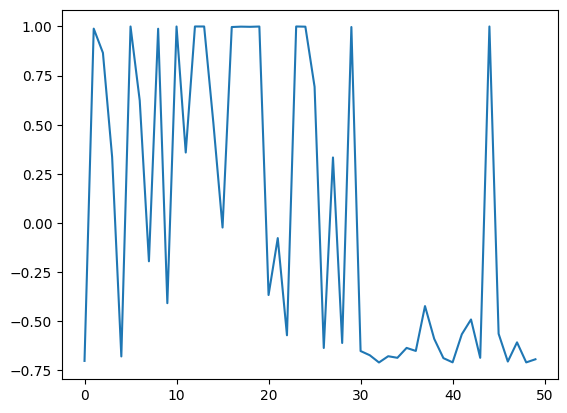

In [57]:
df.loss.plot()

# Obs vs pred of best fit

Best iteration: 33, NSE = 0.710


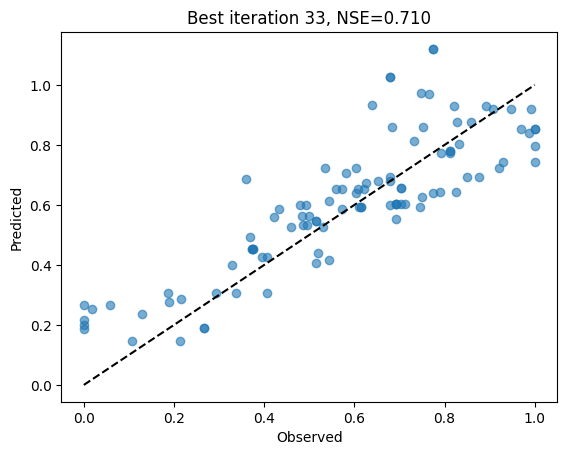

In [58]:

# Find the best iteration (minimum loss)
best_idx = df["loss"].idxmin()
best_row = df.loc[best_idx]
best_iter = best_row["iteration"]

print(f"Best iteration: {best_iter}, NSE = {-best_row['loss']:.3f}")

# Plot Obs vs Pred for the best iteration
plt.figure()
plt.scatter(best_row["obs"], best_row["pred"], alpha=0.6)
plt.plot(
    [best_row["obs"].min(), best_row["obs"].max()],
    [best_row["obs"].min(), best_row["obs"].max()],
    "k--"
)
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title(f"Best iteration {best_iter}, NSE={-best_row['loss']:.3f}")
plt.show()



array([[<Axes: xlabel='[Phenology].JuvenileBase.FixedValue', ylabel='Partial dependence'>,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='[Phenology].VernSensitivity.FixedValue'>,
        <Axes: xlabel='[Phenology].VernSensitivity.FixedValue', ylabel='Partial dependence'>,
        <Axes: >],
       [<Axes: xlabel='[Phenology].JuvenileBase.FixedValue', ylabel='[Phenology].InductivePpSensitivity.FixedValue'>,
        <Axes: xlabel='[Phenology].VernSensitivity.FixedValue'>,
        <Axes: xlabel='[Phenology].InductivePpSensitivity.FixedValue', ylabel='Partial dependence'>]],
      dtype=object)

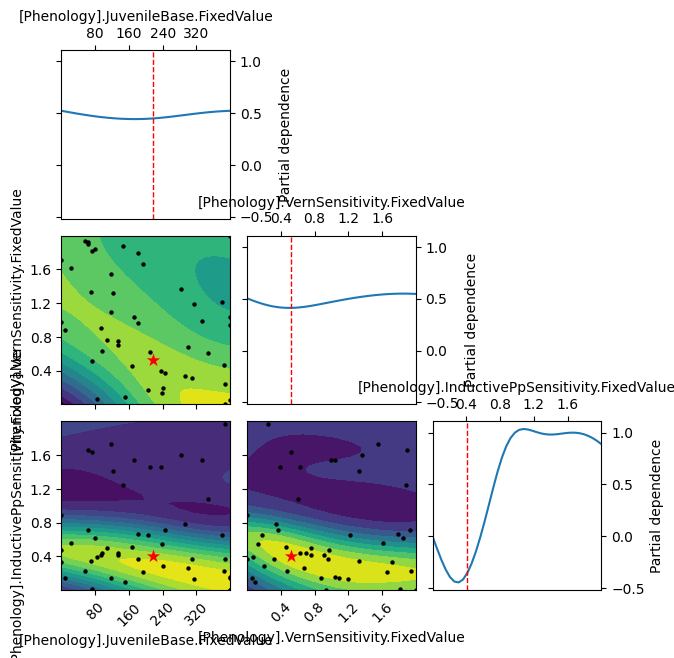

In [59]:
from skopt.plots import plot_objective
from skopt.utils import create_result

res = create_result(
    Xi=opt.Xi,
    yi=np.array(opt.yi),
    space=opt.space,
    specs=None,
    models=opt.models
)

plot_objective(res)